## set up the grid


In [1]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

(450, 90)
RAC2d (40500,)
(100,)


In [2]:
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT
from create_aste90_layers import bin_3d_term_to_TS,create_TS_mesh

In [3]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [4]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [50]:
# --- Load original edges to get bounds only ---
_T_edges_raw = rdmds(layers_path + "layers2TH").reshape(-1)
_S_edges_raw = rdmds(layers_path + "layers1SLT").reshape(-1)

# --- Define bin count and recompute uniform edges ---
# adding a number of bins here will allow us to perform the limit for small/large nT or nS
nT = 70
nS = 70

nT = 150
nS = 150

#T_edges = np.linspace(_T_edges_raw[0], _T_edges_raw[-1], nT + 1)                             # boundsT
#S_edges = np.linspace(_S_edges_raw[0], _S_edges_raw[-1], nS + 1)                             # boundsS
T_edges = _T_edges_raw
S_edges = _S_edges_raw
boundsT,boundsS = T_edges,S_edges
nT,nS = 112,112

# --- Everything else derived programmatically ---
T_centers      = 0.5 * (T_edges[:-1] + T_edges[1:])                                          # binmidT, binsTH_centers
S_centers      = 0.5 * (S_edges[:-1] + S_edges[1:])                                          # binmidS, binsSLT_centers
binmidT = T_centers
binmidS = S_centers

dT_edges       = T_edges[1:] - T_edges[:-1]                                                  # binwidthT
dS_edges       = S_edges[1:] - S_edges[:-1]                                                  # binwidthS

# these are the points we normalize for the J term --  i
dT_centers     = 0.5 * (dT_edges[:-1] + dT_edges[1:])                                        # binwidthT1
dS_centers     = 0.5 * (dS_edges[:-1] + dS_edges[1:])                                        # binwidthS1
binwidthT1 = dT_centers
binwidthS1 = dS_centers

T_inner_edges  = T_edges[1:-1]                                                               # binmidTp
S_inner_edges  = S_edges[1:-1]                                                               # binmidSp

T_edges_2d,       S_edges_2d       = np.meshgrid(T_edges,       S_edges)
T_centers_2d,     S_centers_2d     = np.meshgrid(T_centers,     S_centers)
T_inner_edges_2d, S_inner_edges_2d = np.meshgrid(T_inner_edges, S_inner_edges)

dT_3d, dS_3d = np.meshgrid(dT_edges, dS_edges)
dT_3d = dT_3d.reshape(nS, nT, 1)
dS_3d = dS_3d.reshape(nS, nT, 1)

# set the mesh for plotting
binmidTp = T_edges[1:-1]
binmidSp = S_edges[1:-1]
Tbin2,Sbin2 = np.meshgrid(binmidTp,binmidSp) # for plotting the J terms individually as vectors!
bincentTp = T_centers[1:-1]
bincentSp = S_centers[1:-1]
Sbin3,Tbin3 = Sbin2[1:-1,1:-1],Tbin2[1:-1,1:-1]    # this is now correct, should be same placement as edges but -1 on both ends

In [51]:
print(Sbin2.shape,Sbin3.shape)

(111, 111) (109, 109)


In [6]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [7]:
# load the mask in 1D to get the points from offline

# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)
ind2d = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1
# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan
ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

# load the indices for layers
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing

In [8]:
# iwet_mine.shape

## calculate eq. 1--3 and walkthrough

In [9]:
# load the LAYERS diagnostics
dt = 1800 # single time step

In [10]:
ffac=1e-6
G_T=np.array([])
metaT=parsemeta(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[1] + ".meta")
nFldsT = metaT["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
fldsIwant = np.array(['LaTh2TH','LaTz2TH'])

# check for the correct diagnostics
metaT['fldList']   # 13, 14, 15, 16, 19, 22
b = metaT['fldList']
ifldT = np.array([1,2])    # surf, hDiff, vDiff, hADV, vADV, total tend
# print(np.array(b)[ifldT])  # for G_T

# remake the following to look for the existing terms and see if we can recreate
# ['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
ifldT = np.array([0,1,2,7,8,11])
print(np.array(b)[ifldT])  # for G_T


# we will just do the exact same thing for all the terms
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[1] + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setStend=nFldsS.copy()

# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

24
['LaTs2TH' 'LaTh2TH' 'LaTz2TH' 'LTha2TH' 'LTza2TH' 'LTto2TH']
24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [11]:
# load G_T and G_S for this specific point online
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.

name = "BarentsS"
G_T = {}
G_T[name] = {}
ts = tsstr[1]
    
# now loop through
G_T[name][ts] = {}
for i in range(len(ifldT)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Ttend." + tsstr[-1] + ".data", nx*ny*(nT-1),ifldT[i])
    tmp = np.reshape(tmp,(nT-1,nx*ny))
    tmp = tmp * (rac2dtile * hf2dtile) #* ffac

    if i == ifldT.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residT = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residT = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_T[name][ts][setTtend[ifldT[i]]] = a

# residT was wrong here so we can just ignore

# let's try to verify with G_T first and then start with G_S
# make the G_T term
# we did not mask this or the other one which is why they are the same
# try to make sure we maskt this here.
metaS=parsemeta(layers_path + "diags/LAYERS/layers_3d_Stend." + "0000000003" + ".meta")
nFldsS = metaS["fldList"]
print(len(nFldsT))
setTtend=nFldsT.copy()
# check for the correct diagnostics
metaS['fldList']   # 13, 14, 15, 16, 19, 22
b = metaS['fldList']
# ['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']
ifldS = np.array([12,13,14,19,20,23])

# print(b[12,13,14,19,20,23])
print(np.array(b)[ifldS])  # for G_S

# make the G_T term
G_S = {}
G_S["BarentsS"] = {}
    
# now loop through
G_S["BarentsS"][ts] = {}
for i in range(len(ifldS)-1, -1, -1):
    tmp = read_float64_skip(layers_path + "diags/LAYERS/layers_3d_Stend." + tsstr[-1] + ".data", nx*ny*(nS-1),ifldS[i])
    tmp = np.reshape(tmp,(nS-1,nx*ny))

    # here we will want to multiply by the mask for the Barents Sea
    tmp = tmp * mymsk_1dtile * (rac2dtile * hf2dtile) #* ffac

    if i == ifldS.shape[0]-1:
        # if LTto2TH, do not remove from residual
        residS = tmp
    else:
        # else if vADV, hADV, vDiff, hDiff, surface, remove from residual
        residS = residT-tmp
    
    # just do the Barents Sea for this one
    a = np.nansum(tmp[:,iwet_mine],axis=1)
    G_S["BarentsS"][ts][setTtend[ifldS[i]]] = a


24
['LaSs1SLT' 'LaSh1SLT' 'LaSz1SLT' 'LSha1SLT' 'LSza1SLT' 'LSto1SLT']


In [12]:
# reorganize teh order of these
print(G_T['BarentsS'][ts].keys())
print(G_S['BarentsS'][ts].keys())

# the order of these is tend, advr, advh, dfr, dfh, surf

new_order = ['LTha2TH', 'LTza2TH', 'LaTh2TH', 'LaTz2TH', 'LaTs2TH', 'LTto2TH']
dT = G_T['BarentsS'][ts]
G_T['BarentsS'][ts] = {k: dT[k] for k in new_order}


new_order = ['LTha1SLT', 'LTza1SLT', 'LaTh1SLT', 'LaTz1SLT', 'LaTs1SLT', 'LTto1SLT']
dS = G_S['BarentsS'][ts]
G_S['BarentsS'][ts] = {k: dS[k] for k in new_order}

dict_keys(['LTto2TH', 'LTza2TH', 'LTha2TH', 'LaTz2TH', 'LaTh2TH', 'LaTs2TH'])
dict_keys(['LTto1SLT', 'LTza1SLT', 'LTha1SLT', 'LaTz1SLT', 'LaTh1SLT', 'LaTs1SLT'])


### Load the offline version

In [138]:
# load the G_S and G_T for offline for the same column in the package
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

# load these terms 
dt = 1800

MsumT,dF_Tnew = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=False,debug=False)
MsumS,dF_Snew = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=False,debug=False)
# these have advh, advr, dfh, dfr, surf, kpp, tend and have not been normalized


# verify these are closed
labels = np.array(["ADVh","ADVr","DFh","DFr","kpp","surf","tend"])
for i in range(6):
    print(labels[i],np.nansum(dF_Tnew[i]/dT_centers),"m^3/s")

print()
print(np.nansum(dF_Tnew[:-1]/dT_centers),"m^3/s")
print(np.nansum(dF_Tnew[-1]/dT_centers),"m^3/s")
print()

# do the same for the salt budget

labels = np.array(["ADVh","ADVr","DFh","DFr","kpp","surf","tend"])
for i in range(6):
    print(labels[i],np.nansum(dF_Snew[i]/dS_centers),"m^3/s")

print()
print(np.nansum(dF_Snew[:-1]/dS_centers),"m^3/s")
print(np.nansum(dF_Snew[-1]/dS_centers),"m^3/s")

ADVh 28472946.473357048 m^3/s
ADVr 1135184.1328710548 m^3/s
DFh 23187.004641713484 m^3/s
DFr 26690516.63314718 m^3/s
kpp -76598917.70469984 m^3/s
surf 764966.4242741417 m^3/s

-19512117.036408726 m^3/s
-19512117.036413595 m^3/s

ADVh -17571558.60021411 m^3/s
ADVr -3.725290298461914e-08 m^3/s
DFh 4839.191691300385 m^3/s
DFr -6.548361852765083e-10 m^3/s
kpp -1170882.4969745222 m^3/s
surf -2.9103830456733704e-11 m^3/s

-18737601.90549736 m^3/s
-18737601.905624043 m^3/s


In [14]:
# make a new plot that leaves things as surface, advh, internal, gates, and total tend
internalGT_on = G_T['BarentsS'][ts]['LTza2TH'] + G_T['BarentsS'][ts]['LaTh2TH'] + G_T['BarentsS'][ts]['LaTz2TH']
surfGT_on = G_T['BarentsS'][ts]['LaTs2TH']
advhGT_on = G_T['BarentsS'][ts]['LTha2TH']
tendGT_on = internalGT_on + surfGT_on + advhGT_on

internalGS_on = G_S['BarentsS'][ts]['LTza1SLT'] + G_S['BarentsS'][ts]['LaTh1SLT'] + G_S['BarentsS'][ts]['LaTz1SLT']
surfGS_on = G_S['BarentsS'][ts]['LaTs1SLT']
advhGS_on = G_S['BarentsS'][ts]['LTha1SLT']
tendGS_on = internalGS_on + surfGS_on + advhGS_on

int_idxs = np.array([1,2,3,5])
internalGT_off = np.nansum(dF_Tnew[int_idxs],axis=0)/binwidthT1
surfGT_off = dF_Tnew[4]/binwidthT1
advhGT_off = dF_Tnew[0]/binwidthT1
tendGT_off = internalGT_off + advhGT_off + surfGT_off

internalGS_off = np.nansum(dF_Snew[int_idxs],axis=0)/binwidthS1
surfGS_off = dF_Snew[4]/binwidthS1
advhGS_off = dF_Snew[0]/binwidthS1
tendGS_off = internalGS_off + advhGS_off + surfGS_off


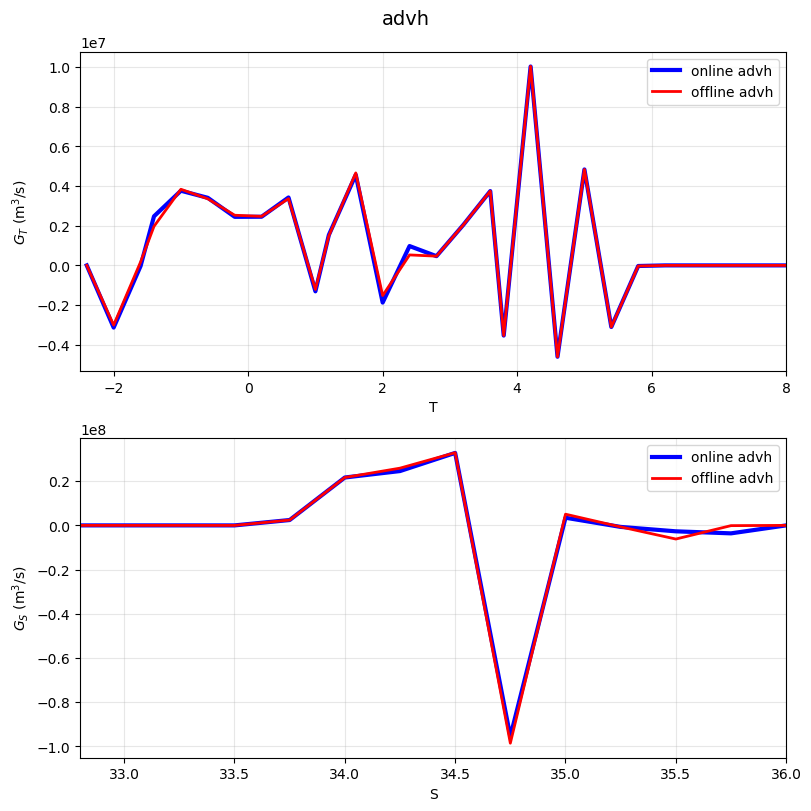

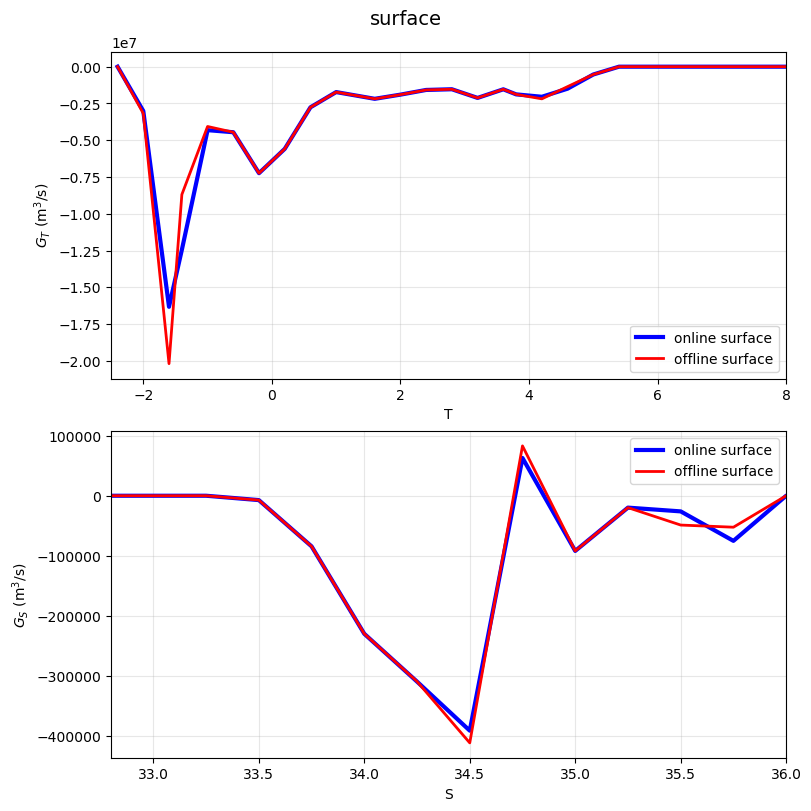

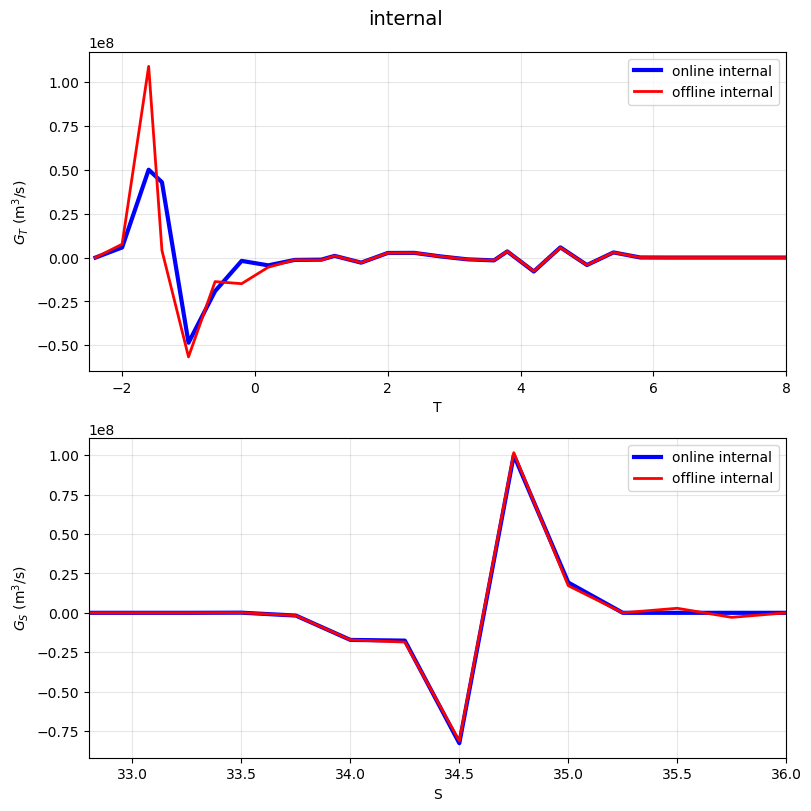

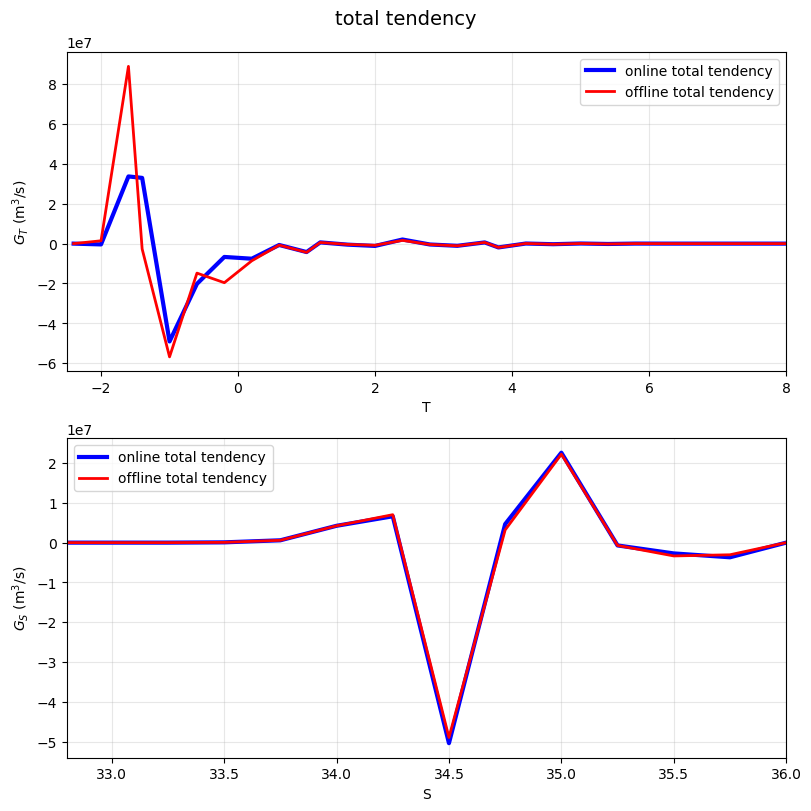

In [15]:
grouped_terms = {
    "advh": {
        "GT_on": advhGT_on,
        "GT_off": advhGT_off,
        "GS_on": advhGS_on,
        "GS_off": advhGS_off,
    },
    "surface": {
        "GT_on": surfGT_on,
        "GT_off": surfGT_off,
        "GS_on": surfGS_on,
        "GS_off": surfGS_off,
    },
    "internal": {
        "GT_on": internalGT_on,
        "GT_off": internalGT_off,
        "GS_on": internalGS_on,
        "GS_off": internalGS_off,
    },
    "total tendency": {
        "GT_on": tendGT_on,
        "GT_off": tendGT_off,
        "GS_on": tendGS_on,
        "GS_off": tendGS_off,
    },
}


def plot_grouped_G(term_name, boundsS, boundsT, grouped_terms,
                   xlimT=(-2.5, 8), xlimS=(32.8, 36)):
    term = grouped_terms[term_name]

    xT = boundsT.flatten()[1:-1]
    xS = boundsS.flatten()[1:-1]

    fig, axes = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

    # GT
    axes[0].plot(xT, term["GT_on"], c="blue", linewidth=3,
                 label=f"online {term_name}")
    axes[0].plot(xT, term["GT_off"], c="red", linewidth=2,
                 label=f"offline {term_name}")
    axes[0].set_ylabel(r"$G_T$ (m$^3$/s)")
    axes[0].set_xlabel("T")
    axes[0].set_xlim(*xlimT)
    axes[0].legend(loc="best")
    axes[0].grid(True, alpha=0.3)

    # GS
    axes[1].plot(xS, term["GS_on"], c="blue", linewidth=3,
                 label=f"online {term_name}")
    axes[1].plot(xS, term["GS_off"], c="red", linewidth=2,
                 label=f"offline {term_name}")
    axes[1].set_ylabel(r"$G_S$ (m$^3$/s)")
    axes[1].set_xlabel("S")
    axes[1].set_xlim(*xlimS)
    axes[1].legend(loc="best")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(term_name, fontsize=14)
    plt.show()


# plot all grouped terms
for name in ["advh", "surface", "internal", "total tendency"]:
    plot_grouped_G(name, boundsS, boundsT, grouped_terms)

In [16]:
# quickly validate the internal gates
print(MsumT['Msum'].sum()-dF_Tnew[0].sum())
print(MsumS['Msum'].sum()-dF_Snew[0].sum())

0.0
-9.313225746154785e-10


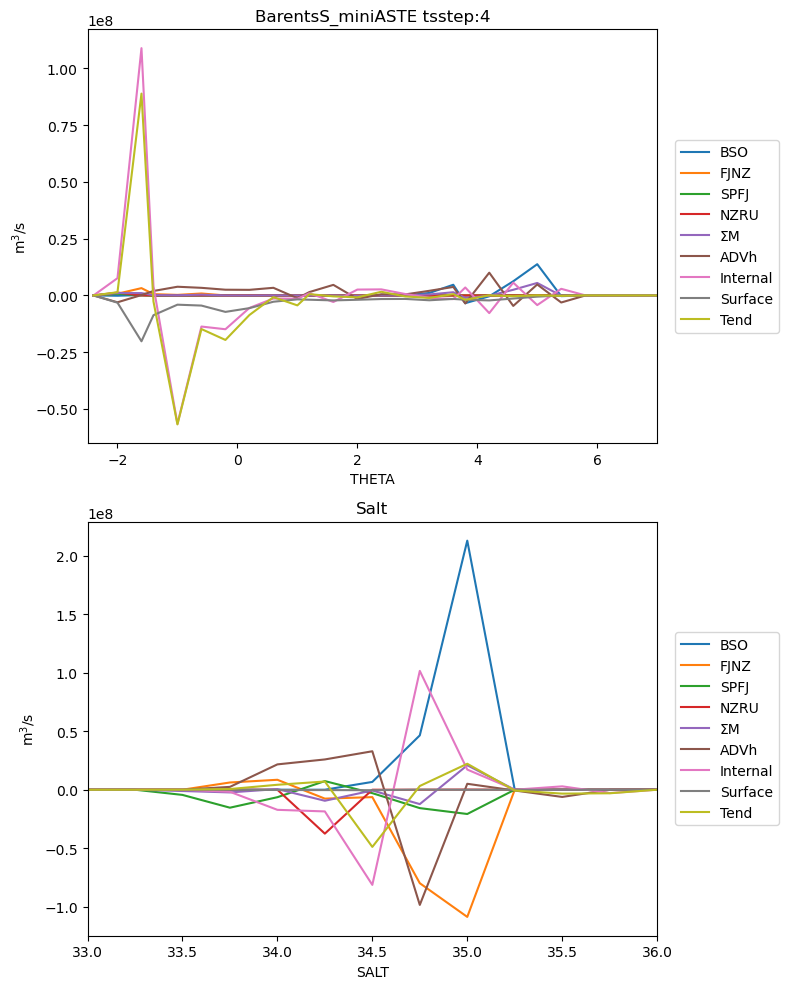

In [17]:
fig = plt.figure(figsize=(8, 10))

xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

# Temperature
ax1 = plt.subplot(211)

for key in list(MsumT.keys())[:4]:
    ax1.plot(xT, MsumT[key] / binwidthT1, label=key)

ax1.plot(xT, MsumT['Msum'], label="ΣM")
ax1.plot(xT, advhGT_off, label="ADVh")
ax1.plot(xT, internalGT_off, label="Internal")
ax1.plot(xT, surfGT_off, label="Surface")
ax1.plot(xT, tendGT_off, label="Tend")

ax1.set_xlim(-2.5, 7)
ax1.set_ylabel("m$^3$/s")
ax1.set_title("BarentsS_miniASTE tsstep:" + str(t2))
ax1.set_xlabel("THETA")

# move legend to the far right
ax1.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))


# Salinity
ax2 = plt.subplot(212)

for key in list(MsumS.keys())[:4]:
    ax2.plot(xS, MsumS[key] / binwidthS1, label=key)

ax2.plot(xS, MsumS['Msum'], label="ΣM")
ax2.plot(xS, advhGS_off, label="ADVh")
ax2.plot(xS, internalGS_off, label="Internal")
ax2.plot(xS, surfGS_off, label="Surface")
ax2.plot(xS, tendGS_off, label="Tend")
ax2.set_xlim(33,36)

ax2.set_ylabel("m$^3$/s")
ax2.set_xlabel("SALT")
ax2.set_title("Salt")
ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()

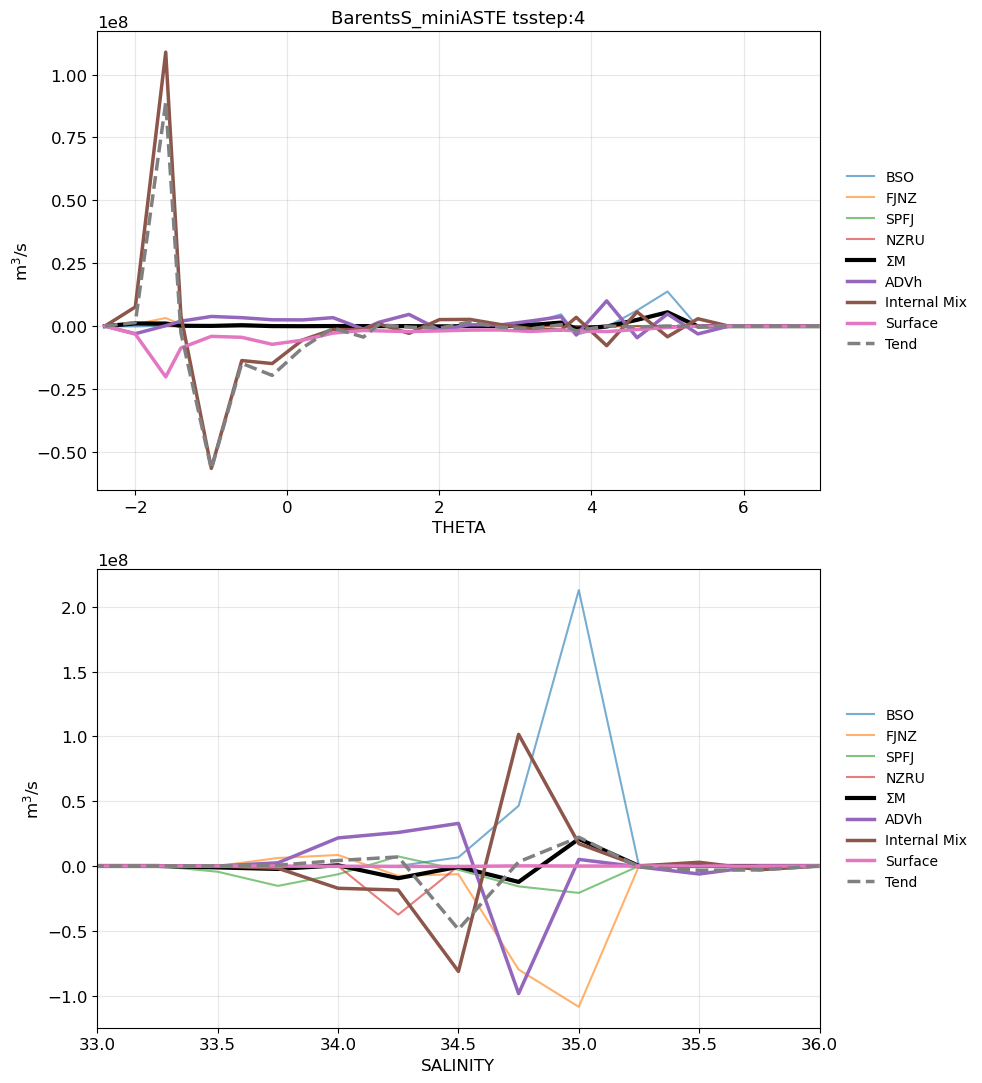

In [121]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 11))

xT = boundsT.flatten()[1:-1]
xS = boundsS.flatten()[1:-1]

# Optional: cleaner default styling
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10
})

# -------------------------
# Temperature
# -------------------------
ax1 = plt.subplot(211)

# lighter, secondary lines
for key in list(MsumT.keys())[:4]:
    ax1.plot(
        xT, MsumT[key] / binwidthT1,
        lw=1.5, alpha=0.6, linestyle='-',
        label=key
    )

# main lines emphasized
ax1.plot(xT, MsumT['Msum'],      lw=3.0, color='k', label="ΣM")
ax1.plot(xT, advhGT_off,         lw=2.5, label="ADVh")
ax1.plot(xT, internalGT_off,     lw=2.5, label="Internal Mix")
ax1.plot(xT, surfGT_off,         lw=2.5, label="Surface")
ax1.plot(xT, tendGT_off,         lw=2.5, linestyle='--', color='gray', label="Tend")

ax1.set_xlim(-2.5, 7)
ax1.set_ylabel("m$^3$/s")
ax1.set_title("BarentsS_miniASTE tsstep:" + str(t2))
ax1.set_xlabel("THETA")
ax1.grid(alpha=0.3)

ax1.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# -------------------------
# Salinity
# -------------------------
ax2 = plt.subplot(212)

for key in list(MsumS.keys())[:4]:
    ax2.plot(
        xS, MsumS[key] / binwidthS1,
        lw=1.5, alpha=0.6, linestyle='-',
        label=key
    )

ax2.plot(xS, MsumS['Msum'],      lw=3.0, color='k', label="ΣM")
ax2.plot(xS, advhGS_off,         lw=2.5, label="ADVh")
ax2.plot(xS, internalGS_off,     lw=2.5, label="Internal Mix")
ax2.plot(xS, surfGS_off,         lw=2.5, label="Surface")
ax2.plot(xS, tendGS_off,         lw=2.5, linestyle='--', color='gray', label="Tend")

ax2.set_xlim(33, 36)
ax2.set_ylabel("m$^3$/s")
ax2.set_xlabel("SALINITY")
# ax2.set_title("Salt")
ax2.grid(alpha=0.3)

ax2.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig("sample_volbudg.png",dpi=300)

## Load the J terms and plot on top of the volume distribution

In [122]:
# volume should be binned to 
####################################################################################################
print("doing volume")
# get the total volume
# for mass tendency (m^3/s) - time is not yet included in this block
file_name = 'budg2d_snap_set1'
DRF3d = np.tile(mygrid['DRF'][:,np.newaxis,np.newaxis],(1,ny,nx))

# assuming all files are structured the same
meta_budg2d_snap_set1 = parsemeta(dirbudg + file_name + "." + tsstr[0]+ ".meta")
# try to read this with rec
fldlist = np.array(meta_budg2d_snap_set1['fldList'])
varnames = np.array(['ETAN'])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])

# set for all months
vol = np.zeros((len(tsstr),nz, ny, nx))
#print("volume allocation shape",vol.shape)

for t in range(len(tsstr)):
    tmpvol = np.tile(mygrid['DXG'][np.newaxis,:,:],(50,1,1)) * np.tile(mygrid['DYG'][np.newaxis,:,:],(50,1,1)) * DRF3d

    vol[t,:,:,:] = tmpvol * np.tile(mymsk, (nz, 1, 1))
#######
# get the THETA as a time average
t2 = int(tsstr[1])
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz, ny, nx)
SALT  = SALT.reshape(nz, ny, nx)

THETA = THETA.reshape(nz,ny,nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
SALT = SALT.reshape(nz,ny,nx) #* np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

# bin this to T_center and S_center
T_centers.shape
S_centers.shape

doing volume


(112,)

In [123]:


# create the binned values for theta and salt
binned_theta = bin_array(THETA, T_centers).astype(float)
binned_salinity = bin_array(SALT, S_centers).astype(float)

# anything assigned to the overflow bin becomes NaN
binned_theta[binned_theta == nT] = np.nan
binned_salinity[binned_salinity == nS] = np.nan

maskArc = mymsk
idxs = np.where(maskArc == 1)

# number of actual bins = edges - 1
nT_bins = nT - 1
nS_bins = nS - 1

# if dT and dS are scalars:
vol_mesh = create_TS_mesh(
    binned_theta,
    binned_salinity,
    vol[0],      # or the correct time slice matching THETA/SALT
    idxs,
    nT_bins,
    nS_bins,
    dT_centers,
    dS_centers
)

In [124]:
vol_mesh[vol_mesh==0] = np.nan

(-2.0, 10.0)

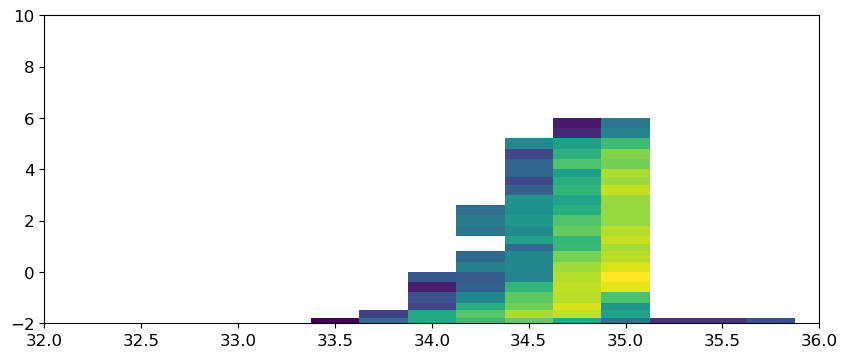

In [125]:
plt.pcolormesh(Sbin2,Tbin2,np.log10(vol_mesh.T),cmap='viridis')
plt.xlim(32,36)
plt.ylim(-2,10)

In [126]:
# Load the J terms for this (can be offline but should be online as well)

# we can load these but please make sure they're from the correct 

# create the same Jy offline as done before


dt = 1800
MsumT,termsT3D = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
MsumS,termsS3D = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,T_edges,S_edges,mapping=True)
# all in m^3/s/tracer

In [127]:

termsT_TS = {}   # inputs as degC.m^3/s, out as m^3/s/PSU, same as layers Jy
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))
for k, arr3d in termsT3D.items():
    termsT_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

termsS_TS = {}   # inputs as PSU.m^3/s, out as m^3/s/degC, same as layers Jx
for k, arr3d in termsS3D.items():
    termsS_TS[k], _, _ = bin_3d_term_to_TS(
        arr3d, THETA, SALT, mymsk3d,
        T_centers, S_centers, dT_centers, dS_centers
    )

In [128]:
from create_aste90_layers import get_div

In [129]:
Jy_tend = termsT_TS['tend']   # m^3/s/PSU
Jx_tend = termsS_TS['tend']   # m^3/s/degC
Jy_tend *= 1e-6
Jx_tend *= 1e-6

(-2.0, 10.0)

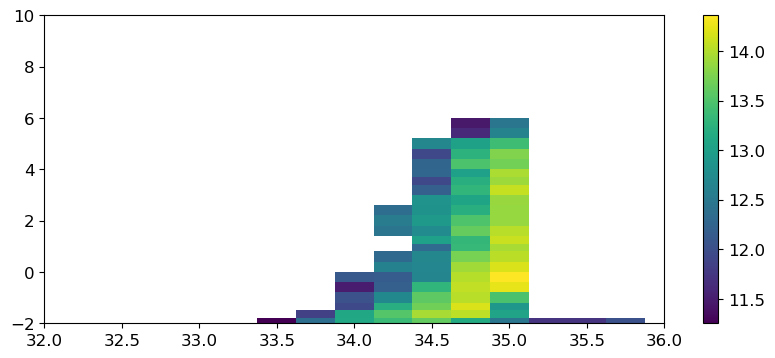

In [130]:
# plot the overall tendency vectors on the volume distribution

fig = plt.figure()

ax = plt.subplot(111)
cb = ax.pcolormesh(Sbin2,Tbin2,np.log10(vol_mesh.T),cmap='viridis')
plt.colorbar(cb)
ax.set_xlim(32,36)
ax.set_ylim(-2,10)

In [131]:
# add the isopycnals
# add the density contours from gsw
smin = 25.5 - (0.01 * 25.5)    #salt_ctrl_subregR.min - (0.01 * salt_ctrl_subregR.min)
smax = 38 + (0.01 * 38)    #salt_ctrl_subregR.max + (0.01 * salt_ctrl_subregR.max)
tmin = -2 + (0.1 * -2)       #temp_ctrl_subregR.min - (0.1 * temp_ctrl_subregR.max)
tmax = 31 + (0.1 * 31)       #temp_ctrl_subregR.max + (0.1 * temp_ctrl_subregR.max)
print('tmin, tmax, smin, smax sizes=,', tmin, tmax, smin, smax)
# Calculate how many gridcells we need in the x and y dimensions
xdim = 50
ydim = 50
# Create empty grid of zeros
dens = np.zeros((ydim,xdim))
# Create temp and salt vectors of appropiate dimensions
ti = np.linspace(-2,31,ydim)
si = np.linspace(25.5,38,xdim)
Freez_temp = gsw.CT_freezing(si,0,0)

Si, Ti = np.meshgrid(si, ti, sparse=False, indexing='ij')
# Loop to fill in grid with densities
for j in range(0,int(ydim)):
    for i in range(0, int(xdim)):
        #print(si[i],ti[j])
        dens[j,i]=gsw.rho(si[i],ti[j],0)
        # Substract 1000 to convert to sigma-0
dens2 = dens - 1000

tmin, tmax, smin, smax sizes=, -2.2 34.1 25.245 38.38


In [132]:
# tsstr

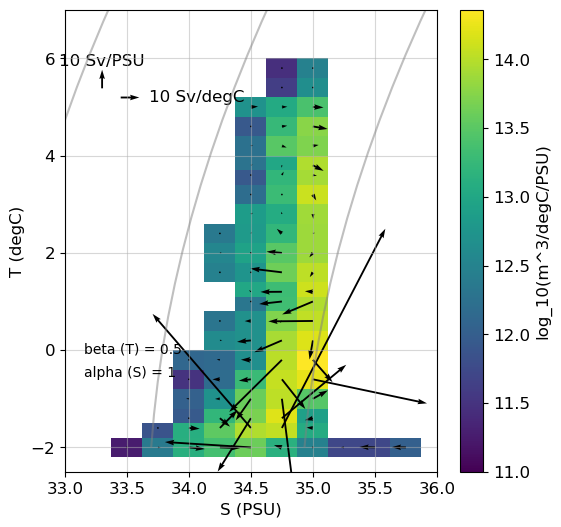

In [136]:
# plot these on a figure to show the budgeted terms
alpha = 1
beta = .5
arrow_length = 10     # for the sverdrup arrows
step=2
t = 0
U = arrow_length
scale = 2e2

xlims = np.array([33,36])
ylims = np.array([-2.5,7])


# first get the values and do conversions to Sv/degC or Sv/PSU
fig = plt.figure(figsize = (6,6))

# total tendency
ax = plt.subplot(111)
cb1 = ax.pcolormesh(Sbin2, Tbin2, np.log10(vol_mesh.T), cmap='viridis', vmin=11)
# Set U1 and V1 and apply alpha and beta scaling

U1, V1 = Jx_tend.T, Jy_tend.T
U1[U1 == 0], V1[V1 == 0] = np.nan, np.nan
U1, V1 = U1 * alpha, V1 * beta
# Plot quiver
q1 = ax.quiver(Sbin2,Tbin2, U1, V1, width=0.005, scale=scale)
plt.colorbar(cb1, label="log_10(m^3/degC/PSU)")
# Set title, limits, and grid
# ax.set_title("total tend " + datetimes[0].strftime("%Y-%m-%d"))
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_xlabel("S (PSU)")
ax.set_ylabel("T (degC)")
ax.grid(alpha=0.5)
# Add the quiver key for Sv/PSU
# Adjust X and Y to position the quiver key appropriately on the plot
quiver_length = 1.0  # Set the length of the arrow for the key
ax.quiverkey(q1,X=0.2,Y=0.81,U = U,label=str(U) + " Sv/degC",labelpos='E')
ax.quiverkey(q1, X=0.1, Y=0.85, U=U, label=str(U) + " Sv/PSU",angle=90, labelpos='N', coordinates='axes')

# Add alpha and beta text to the plot
ax.text(0.05, 0.2, f'alpha (S) = {alpha}', transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom')
ax.text(0.05, 0.25, f'beta (T) = {beta}', transform=ax.transAxes, fontsize=10, color='black', verticalalignment='bottom')
# Add density contours
cs = ax.contour(si, ti, dens2, colors="grey", zorder=2, alpha=0.5, levels=np.arange(16, 32, 1))
cl = ax.clabel(cs, fontsize=10, inline=False, fmt="%.f")

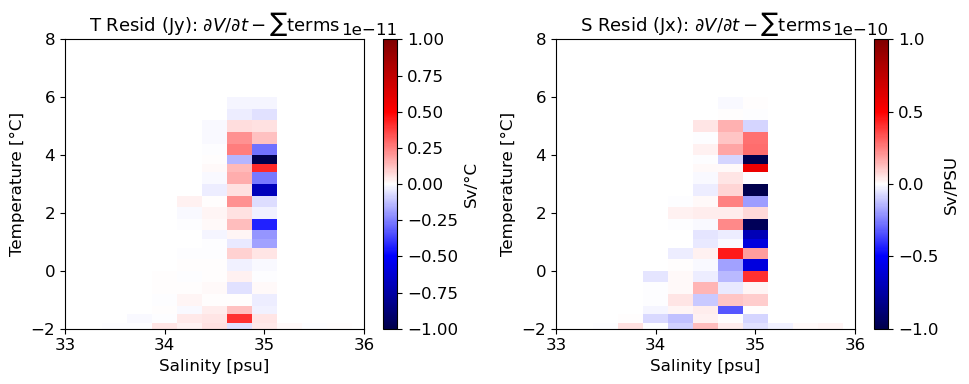

In [85]:
# quickly check the closure of the Jy and Jx terms

fig = plt.figure(figsize=(10, 4))

# --- Temperature (Jy) ---
ax = plt.subplot(121)

LHS = termsT_TS['tend']
RHS = (
    termsT_TS['ADVh'] + termsT_TS['ADVr'] +
    termsT_TS['DFhT'] + termsT_TS['DFrT'] +
    termsT_TS['surf'] + termsT_TS['KPP']
)
RHS *= 1e-6

cb = ax.pcolormesh(
    Sbin2, Tbin2, (LHS - RHS).T,
    cmap='seismic', vmin=-1e-11, vmax=1e-11
)
plt.colorbar(cb, ax=ax, label='Sv/°C')

ax.set_title(r'T Resid (Jy): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)

# --- Salinity (Jx) ---
ax = plt.subplot(122)

LHS = termsS_TS['tend']
RHS = (
    termsS_TS['ADVh'] + termsS_TS['ADVr'] +
    termsS_TS['DFhS'] + termsS_TS['DFrS'] +
    termsS_TS['surf'] + termsS_TS['KPP']
)
RHS *= 1e-6

cb = ax.pcolormesh(
    Sbin2, Tbin2, (LHS - RHS).T,
    cmap='seismic', vmin=-1e-10, vmax=1e-10
)
plt.colorbar(cb, ax=ax, label='Sv/PSU')

ax.set_title(r'S Resid (Jx): $\partial V/\partial t - \sum \mathrm{terms}$')
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_xlim(33, 36)
ax.set_ylim(-2, 8)

plt.tight_layout()
plt.show()

# plot the divergences

In [144]:
ttend = termsT_TS['tend']
stend = termsS_TS['tend']
ttend[np.isnan(ttend)] = 0
stend[np.isnan(stend)] = 0

In [145]:
# we still need the gateway contributions, binned at the gate face THETA/SALT

T_keys = list(termsT_TS.keys())
S_keys = list(termsS_TS.keys())

# total tendency
dVdt = get_div(ttend, stend, dT_centers, dS_centers)

# example single term
divADVh = get_div(termsT_TS['ADVh'], termsS_TS['ADVh'], dT_centers, dS_centers)

divDFh = get_div(termsT_TS['DFhT'], termsS_TS['DFhS'], dT_centers, dS_centers)


# internal = sum of terms at positions 1,2,3,5
internal_inds = [1, 2, 3, 5]

divint = sum(
    get_div(termsT_TS[T_keys[i]], termsS_TS[S_keys[i]], dT_centers, dS_centers)
    for i in internal_inds
)

# surface = term at position 4
surface_ind = 4
divsurf = get_div(termsT_TS[T_keys[surface_ind]],termsS_TS[S_keys[surface_ind]],dT_centers,dS_centers)

In [146]:
BSO_div = get_div(MsumT['BSO_TS'], MsumS['BSO_TS'], dT_centers, dS_centers)
FJNZ_div = get_div(MsumT['FJNZ_TS'], MsumS['FJNZ_TS'], dT_centers, dS_centers)
SPFJ_div = get_div(MsumT['SPFJ_TS'], MsumS['SPFJ_TS'], dT_centers, dS_centers)
NZRU_div = get_div(MsumT['NZRU_TS'], MsumS['NZRU_TS'], dT_centers, dS_centers)
Msum_div = get_div(MsumT['Msum_TS'], MsumS['Msum_TS'], dT_centers, dS_centers)

In [147]:
# BSO_div = get_div(MsumT['BSO_TS'], MsumS['BSO_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, BSO_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('BSO TS Diagram')
# plt.show()

# FJNZ_div = get_div(MsumT['FJNZ_TS'], MsumS['FJNZ_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, FJNZ_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('FJNZ TS Diagram')
# plt.show()

# SPFJ_div = get_div(MsumT['SPFJ_TS'], MsumS['SPFJ_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, SPFJ_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('SPFJ TS Diagram')
# plt.show()

# NZRU_div = get_div(MsumT['NZRU_TS'], MsumS['NZRU_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, NZRU_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('NZRU TS Diagram')
# plt.show()

# Msum_div = get_div(MsumT['Msum_TS'], MsumS['Msum_TS'], dT_centers, dS_centers)
# plt.figure()
# plt.pcolormesh(Sbin3, Tbin3, Msum_div.T, shading='auto')
# plt.colorbar(label='Divergence')
# plt.xlabel('Salinity')
# plt.ylabel('Temperature')
# plt.title('Msum TS Diagram')
# plt.show()

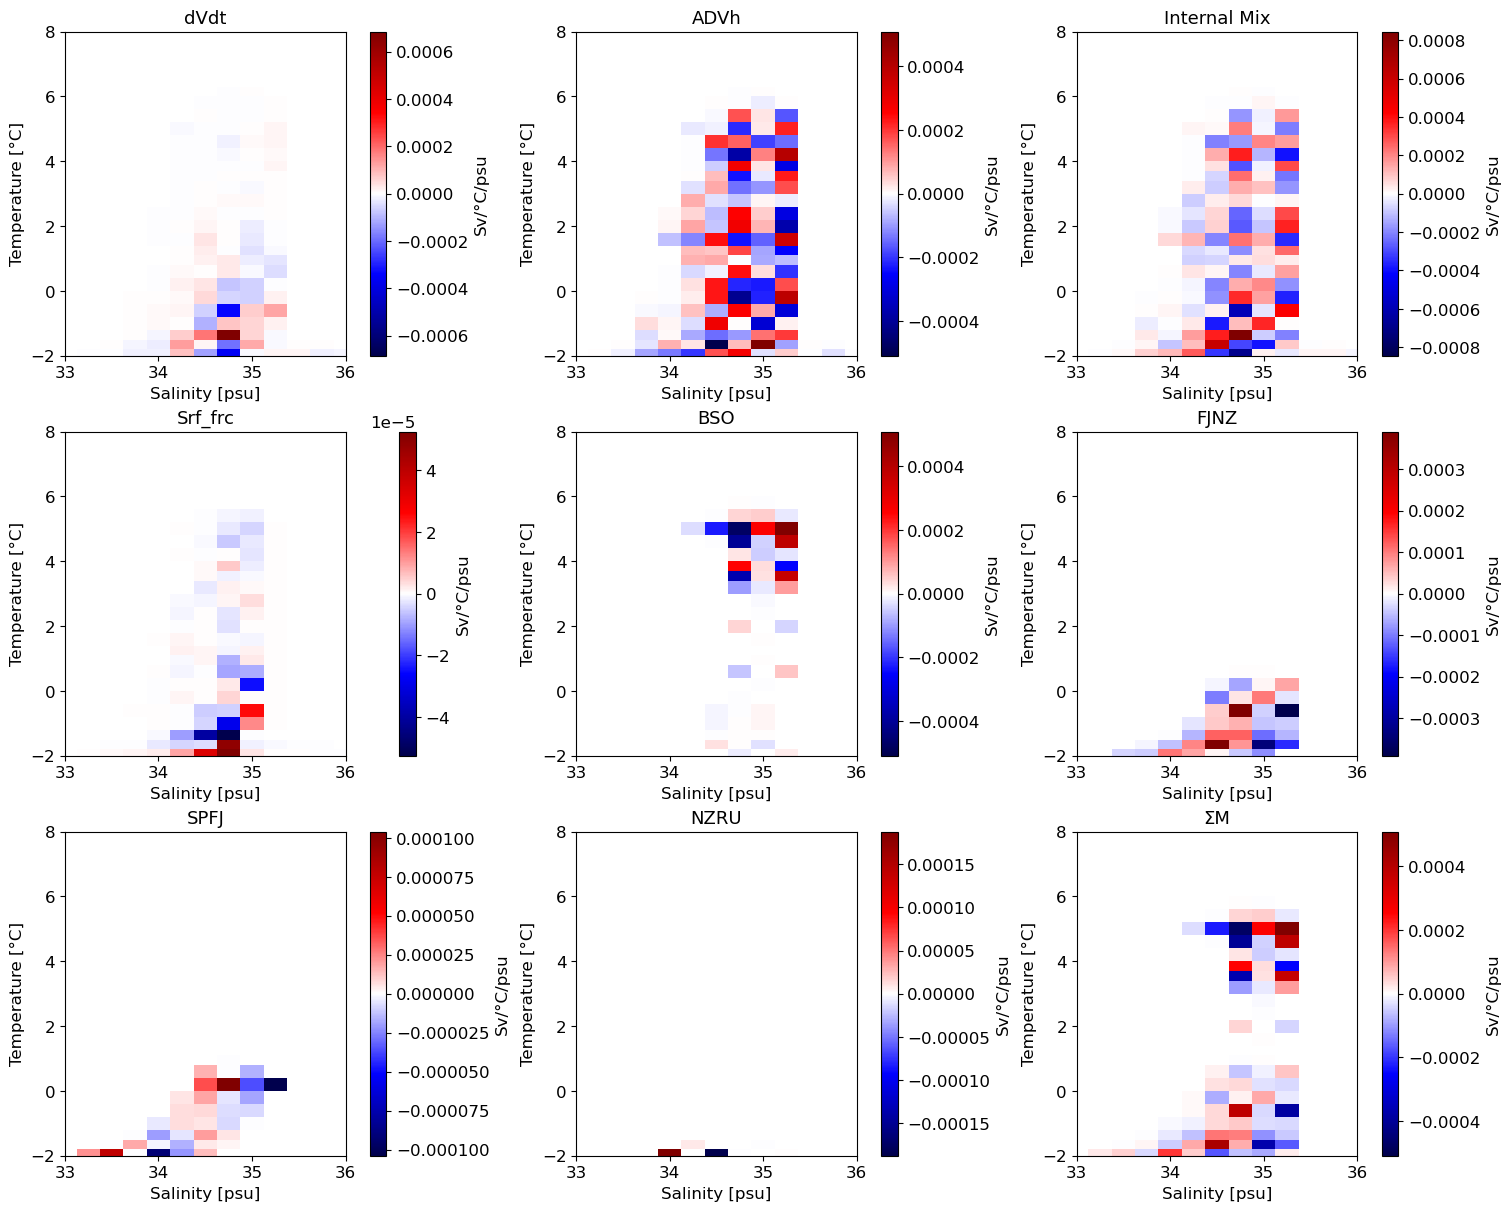

In [148]:
# plot the other terms against this difference
plot_dict = {
    'dVdt': dVdt,
    'ADVh': divADVh*1e-6,
    'Internal Mix': divint*1e-6,
    'Srf_frc': divsurf*1e-6,
    'BSO': BSO_div*1e-6,
    'FJNZ': FJNZ_div*1e-6,
    'SPFJ': SPFJ_div*1e-6,
    'NZRU': NZRU_div*1e-6,
    'ΣM': Msum_div*1e-6,
}

nplots = len(plot_dict)
ncols = 3
nrows = (nplots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

for ax, (name, div) in zip(axes, plot_dict.items()):
    a = div.copy()
    a[a==0] = np.nan
    vlev = np.nanmax(a)
    pcm = ax.pcolormesh(Sbin3, Tbin3, a.T, shading='auto',cmap='seismic',vmin=-vlev,vmax=vlev)
    ax.set_xlabel('Salinity [psu]')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(name)
    ax.set_xlim(33,36)
    ax.set_ylim(-2,8)
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('Sv/°C/psu')

# remove unused axes
for ax in axes[len(plot_dict):]:
    fig.delaxes(ax)

plt.show()

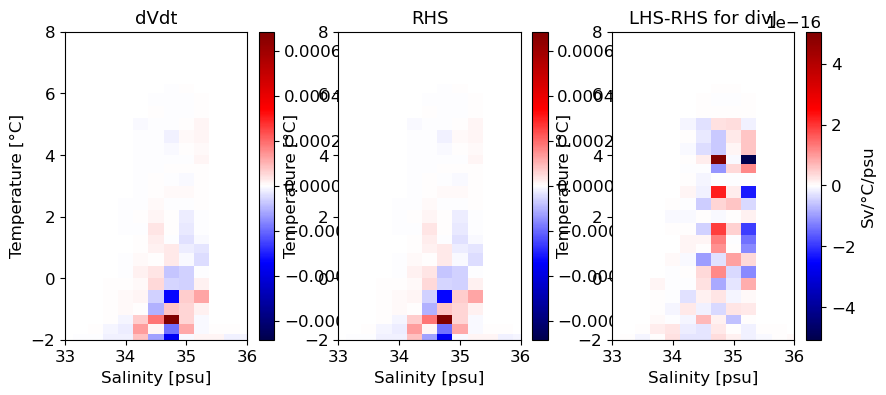

In [150]:
# check the closure of the offline terms without gates

fig = plt.figure()

# plot the overall tendency (dVdt closure)
ax = plt.subplot(131)
a = dVdt.copy()
a[a==0] = np.nan
vlev = np.nanmax(a)
pcm = ax.pcolormesh(Sbin3, Tbin3, a.T, shading='auto',cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_title("dVdt")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Sv/°C/psu')

# sum of the other terms
ax = plt.subplot(132)
b = (divADVh + divint + divsurf)*1e-6
b[b==0] = np.nan
vlev = np.nanmax(b)
pcm = ax.pcolormesh(Sbin3, Tbin3, b.T, shading='auto',cmap='seismic',vmin=-vlev,vmax=vlev)
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_title("RHS")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Sv/°C/psu')


# sum of the other terms
ax = plt.subplot(133)
b = (divADVh + divint + divsurf)*1e-6
b[b==0] = np.nan
vlev = np.nanmax(b)
pcm = ax.pcolormesh(Sbin3, Tbin3, (a-b).T, shading='auto',cmap='seismic')#,vmin=-vlev,vmax=vlev)
ax.set_xlabel('Salinity [psu]')
ax.set_ylabel('Temperature [°C]')
ax.set_title("LHS-RHS for divJ")
ax.set_xlim(33,36)
ax.set_ylim(-2,8)
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label('Sv/°C/psu')

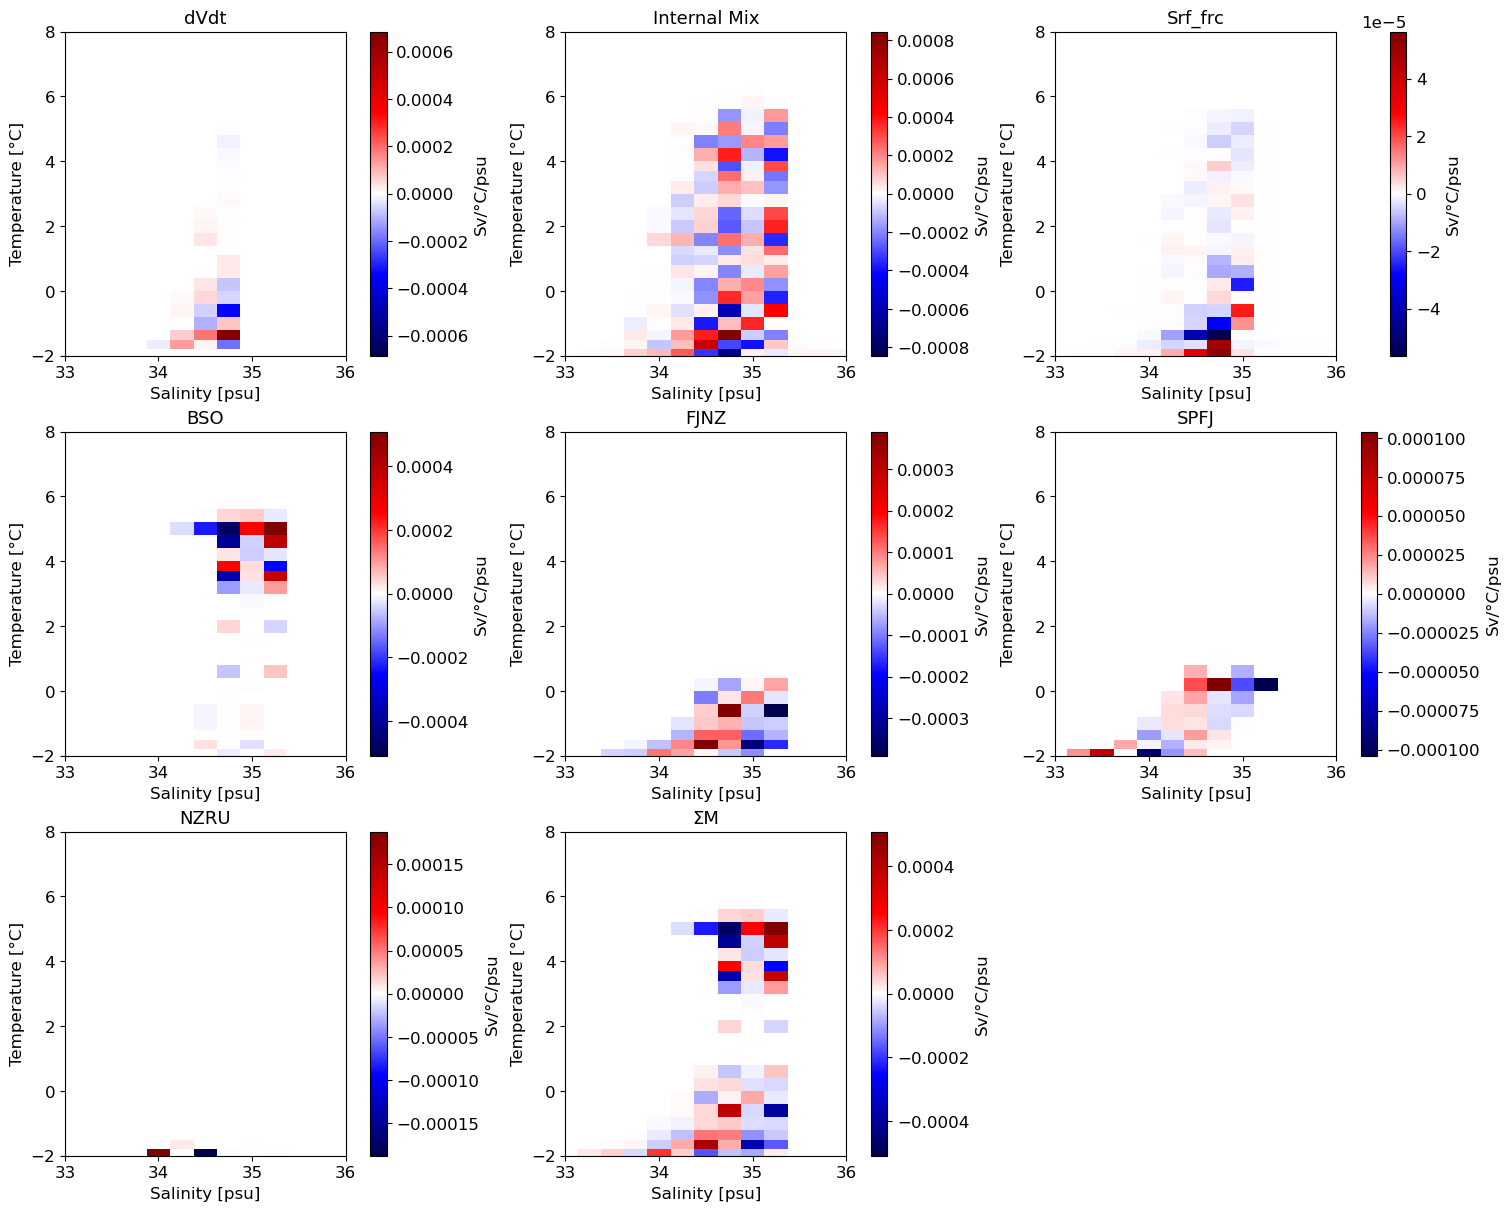

In [137]:
# make another plot which is the four gates, the sum of the gates, internal dVdt
# plot selected terms against the difference
plot_dict = {
    'dVdt': dVdt,
    'Internal Mix': divint * 1e-6,
    'Srf_frc': divsurf * 1e-6,
    'BSO': BSO_div * 1e-6,
    'FJNZ': FJNZ_div * 1e-6,
    'SPFJ': SPFJ_div * 1e-6,
    'NZRU': NZRU_div * 1e-6,
    'ΣM': Msum_div*1e-6,
}

nplots = len(plot_dict)
ncols = 3
nrows = (nplots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True)
axes = axes.flatten()

for ax, (name, div) in zip(axes, plot_dict.items()):
    a = div.copy()
    a[a == 0] = np.nan
    vlev = np.nanmax(np.abs(a))
    
    pcm = ax.pcolormesh(
        Sbin3, Tbin3, a.T,
        shading='auto',
        cmap='seismic',
        vmin=-vlev,
        vmax=vlev
    )
    ax.set_xlabel('Salinity [psu]')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(name)
    ax.set_xlim(33, 36)
    ax.set_ylim(-2, 8)
    
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label('Sv/°C/psu')

# remove unused axes
for ax in axes[len(plot_dict):]:
    fig.delaxes(ax)

plt.savefig("sample_dJ.png",dpi=300)

plt.show()
